# 3. How far did Retail-Plus members' spend fall from Q1 to Q2, month by month?

**Week 2, Thursday. Chapter 3 of 6.** Chapter 2 put the monsoon sale on the growth team's table: 130 customers reached, one row each, and the table still 340 rows and Rs 19,84,00,000. Week 1 found that Retail-Plus members ordered less often in Q2 than in Q1. This chapter turns their orders into months for the head of the tier.

> **The client asks.** "Give me one row per member and one column per month. I want to read
> along a row and see who is drifting, and I want the tier's fall from Q1 to Q2 in one number
> I can take to the growth review."
>
> The head of Retail-Plus, Kalpa Retail

**Who needs the answer.** The head of Retail-Plus, Kalpa's paid membership tier, who takes one
number to the growth review and uses the rows to decide which members to protect. A number
that is too small argues the tier's problem down to a fraction of its size, and rows that
stand for the wrong thing protect the wrong members while the right ones lapse.

**The questions on the way.**

1. Which of three shapes should answer the head of Retail-Plus, and what does each cost?
2. In how many member-months did Retail-Plus actually buy?
3. How far did the tier fall, read from a one-line pivot?
4. What does one row of the pivot stand for?
5. Which shape compares a member's quarters, and which follows the tier's trend?
6. Does a query that never pivots give the same fall?

**The metric at stake.** Retail-Plus spend by month, April to September 2026, and the change in the tier's spend from
Q1, April to June, to Q2, July to September. A month's spend is every order the member placed
in it, at the prices charged, added up.

**Who else faces it.** Costco, whose business rests on paid memberships, reports its sales in the two parts this
chapter has to keep apart. On the call for its fourth quarter of fiscal 2026, its chief
financial officer reported that "traffic or shopping frequency increased 3.3% worldwide" and
that "our average transaction or ticket was up 5.9% worldwide": how often members shop, and
what each trip is worth, as two numbers (Costco's earnings call and the supplemental information
it filed with the SEC, both 24 Sep 2026, checked 1 Oct 2026). The same call put the renewal rate in the
US and Canada at 92.3 percent, the number the head of a paid tier watches first.

`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, the retail dossier, has the business behind these numbers: section 3 for GMV, section 5 for frequency and repeat rate, and section 2 for Retail-Plus, the paid tier.

**Setup.** The next cell reads the orders and the customer list from the warehouse, labels
every order with its month, and keeps the Retail-Plus members' orders.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

ENG = kit.engine()                  # the Kalpa warehouse in Postgres, read only
orders = pd.read_sql(
    "SELECT order_id, customer_id, order_date, quarter, channel, amount, status FROM orders",
    ENG, parse_dates=["order_date"])
customers = pd.read_sql("SELECT customer_id, segment, city FROM customers", ENG)
print(f"{len(orders):,} orders and {len(customers):,} customers read from the warehouse")

orders = orders.assign(month=orders["order_date"].dt.to_period("M").astype(str))
plus = (orders.merge(customers, on="customer_id", how="left", validate="many_to_one")
              .query("segment == 'Retail-Plus'"))
MONTHS = sorted(orders["month"].unique())
print(f"{len(plus)} Retail-Plus orders from {plus['customer_id'].nunique()} members, {MONTHS[0]} to {MONTHS[-1]}")

1,000 orders and 340 customers read from the warehouse
355 Retail-Plus orders from 107 members, 2026-04 to 2026-09


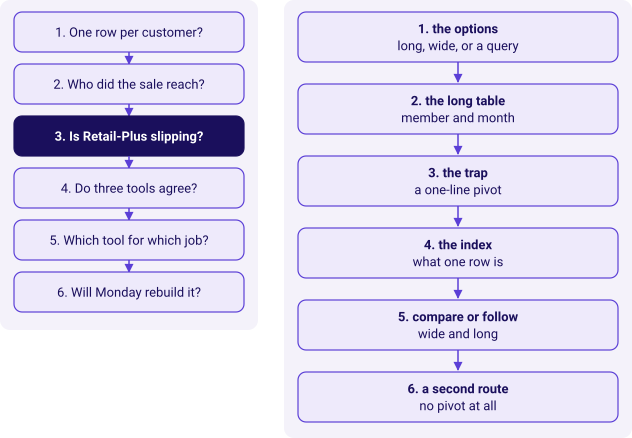

In [2]:
kit.side_by_side(
    kit.ladder(["One row per customer?", "Who did the sale reach?", "Is Retail-Plus slipping?", "Do three tools agree?", "Which tool for which job?", "Will Monday rebuild it?"], lit=2, show=False),
    kit.vflow(["1. the options\nlong, wide, or a query", "2. the long table\nmember and month", "3. the trap\na one-line pivot", "4. the index\nwhat one row is", "5. compare or follow\nwide and long", "6. a second route\nno pivot at all"], show=False),
)

## 1. Which of three shapes should answer the head of Retail-Plus, and what does each cost?

| Option | Shape | What it answers directly |
|---|---|---|
| a) The long table | One row per member per month with orders: `groupby(["customer_id", "month"])` | How the tier moves from month to month, a trend |
| b) The wide table | One row per member, one column per month: `pivot_table`, which turns the values of one column into columns | How a member's months compare, read along a row |
| c) A query per month | SQL with one column per month, each written out by hand with `FILTER` | The wide table, straight from the warehouse |

The next cell sizes each on the Retail-Plus orders: the rows and cells it holds, the empty cells
it carries, and what adding October would cost.

option,shape,cells,empty cells,adding October costs
a) the long table,266 rows by 3,798,0,nothing
b) the wide table,107 rows by 6,642,376,nothing
c) a query per month,107 rows by 7,749,376,"a new FILTER line, typed by hand"


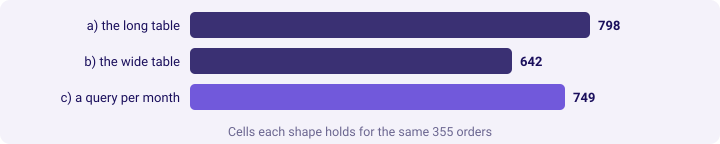

In [3]:
long_ = plus.groupby(["customer_id", "month"], as_index=False)["amount"].sum()
members = plus["customer_id"].nunique()
BY_MONTH = """SELECT o.customer_id,
       sum(o.amount) FILTER (WHERE o.order_date >= DATE '2026-04-01' AND o.order_date < DATE '2026-05-01') AS apr,
       sum(o.amount) FILTER (WHERE o.order_date >= DATE '2026-05-01' AND o.order_date < DATE '2026-06-01') AS may,
       sum(o.amount) FILTER (WHERE o.order_date >= DATE '2026-06-01' AND o.order_date < DATE '2026-07-01') AS jun,
       sum(o.amount) FILTER (WHERE o.order_date >= DATE '2026-07-01' AND o.order_date < DATE '2026-08-01') AS jul,
       sum(o.amount) FILTER (WHERE o.order_date >= DATE '2026-08-01' AND o.order_date < DATE '2026-09-01') AS aug,
       sum(o.amount) FILTER (WHERE o.order_date >= DATE '2026-09-01' AND o.order_date < DATE '2026-10-01') AS sep
FROM   orders o
JOIN   customers c ON c.customer_id = o.customer_id
WHERE  c.segment = 'Retail-Plus'
GROUP  BY o.customer_id
ORDER  BY o.customer_id;"""
sent_c = pd.read_sql(BY_MONTH, ENG)
sizing = [("a) the long table", f"{len(long_)} rows by 3", len(long_) * 3, 0, "nothing"),
          ("b) the wide table", f"{members} rows by 6", members * 6, members * 6 - len(long_), "nothing"),
          ("c) a query per month", f"{len(sent_c)} rows by 7", len(sent_c) * 7, int(sent_c.isna().sum().sum()),
           "a new FILTER line, typed by hand")]
kit.table(["option", "shape", "cells", "empty cells", "adding October costs"], sizing,
          caption="Each shape sized on the 355 Retail-Plus orders")
kit.bars([(name, cells) for name, _, cells, _, _ in sizing], lit=(0, 1),
         title="Cells each shape holds for the same 355 orders")

**The best-fit call: a and b together, in pandas.** The long table keeps every rupee in 266
rows and is the easiest to group and plot; the wide table is the one the head of Retail-Plus
reads along a row, and its 376 empty cells are member-months with no order. The query per month
builds the wide table too, but it fixes the six months in its text, so every new month is an
edit and a place for a typo. **The fact that would change it:** the view moving into the
warehouse to run every Monday for Finance. Then c returns, with a calendar table of months,
Wednesday's idea, in place of the hand-written columns.

## 2. In how many member-months did Retail-Plus actually buy?

Before any pivot, the grain the head of Retail-Plus asked about is member and month. Two keys
in the `groupby` give one row for each member and month that actually has orders, with that
month's orders added up.

**Predict before you run.** How many rows does the long table have? a) 355, one per order;
b) 642, 107 members times 6 months; c) 266; d) 107, one per member.

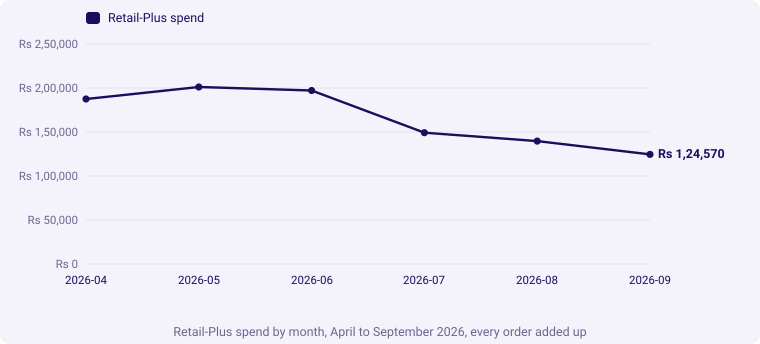

customer_id,month,amount
C-0151,2026-04,"Rs 2,640"
C-0151,2026-06,"Rs 6,290"
C-0151,2026-07,"Rs 2,250"
C-0151,2026-08,"Rs 8,660"
C-0152,2026-05,"Rs 3,170"


In [4]:
tier = long_.groupby("month")["amount"].sum()
kit.line(MONTHS, [("Retail-Plus spend", tier.tolist(), "lit")], fmt=kit.rupees,
         title="Retail-Plus spend by month, April to September 2026, every order added up")
kit.table(["customer_id", "month", "amount"],
          [(r.customer_id, r.month, kit.rupees(r.amount)) for r in long_.head(5).itertuples()],
          caption="The long table's first rows: one member, one month, that month's orders added")

In [5]:
q1, q2 = tier[MONTHS[:3]].sum(), tier[MONTHS[3:]].sum()
kit.check("the long table keeps every rupee", long_["amount"].sum() == plus["amount"].sum(),
          kit.rupees(long_["amount"].sum()))
kit.check("one row per member-month that has orders", len(long_) == 266, f"{len(long_)} rows")
kit.check("the tier took Rs 5,85,770 in Q1 and Rs 4,13,380 in Q2", q1 == 585770 and q2 == 413380,
          f"{kit.rupees(q1)} and {kit.rupees(q2)}")

**What happened.** The answer is c, 266 rows. A member-month with no order has no row at all, so
the long table is shorter than 107 members times 6 months, and the 13 Retail-Plus members who
never ordered, chapter 1's never-ordered customers, are in no row. The line is the number to
hold on to: the tier took Rs 5,85,770 in Q1 and Rs 4,13,380 in Q2.

## 3. How far did the tier fall, read from a one-line pivot?

**The plausible wrong answer.** The analyst asks for months as columns in one line, members as
rows, amounts in the cells, then adds up each month's column for the tier's monthly spend.

**Predict before you run.** What fall from Q1 to Q2 does that pivot report? a) 29 percent;
b) 18 percent; c) 0 percent; d) it raises an error.

In [6]:
wide_wrong = plus.pivot_table(index="customer_id", columns="month", values="amount")
col_wrong = wide_wrong.sum()
q1_w, q2_w = col_wrong[MONTHS[:3]].sum(), col_wrong[MONTHS[3:]].sum()
kit.stats([(kit.rupees(round(q1_w)), "Q1, from the pivot", "April to June"),
           (kit.rupees(round(q2_w)), "Q2, from the pivot", "July to September"),
           (f"{q2_w / q1_w - 1:.0%}", "the change it reports", "what the review would hear")])

**What happened.** The answer is b, a fall of 18 percent.

**Why it is wrong.** `pivot_table` has to put one number in each cell, and when a member placed
several orders in a month it combines them with its default, which is the mean. A member who
ordered four times in June shows the average of the four, and the column sums add up
averages. An average order hides how often members bought, and how often is the lever Week 1
found moving in Retail-Plus. The head of Retail-Plus would walk into the review defending a
fall well under two-thirds of its real size. The check that catches it: a pivot of spend must
hold the same total as the orders it came from.

month,orders,the pivot shows,the member spent
2026-04,0,,Rs 0
2026-05,1,"Rs 3,170.00","Rs 3,170"
2026-06,4,"Rs 2,557.50","Rs 10,230"
2026-07,2,"Rs 2,780.00","Rs 5,560"
2026-08,0,,Rs 0
2026-09,2,"Rs 3,440.00","Rs 6,880"


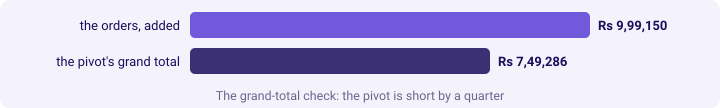

In [7]:
grand_wrong = wide_wrong.sum().sum()
member = "C-0152"
row = [(m, int((plus["customer_id"].eq(member) & plus["month"].eq(m)).sum()),
        "" if pd.isna(wide_wrong.loc[member, m]) else f"Rs {wide_wrong.loc[member, m]:,.2f}",
        kit.rupees(plus.loc[plus["customer_id"].eq(member) & plus["month"].eq(m), "amount"].sum()))
       for m in MONTHS]
kit.table(["month", "orders", "the pivot shows", "the member spent"], row,
          caption=f"One member, {member}, read along the row")
kit.bars([("the orders, added", plus["amount"].sum()), ("the pivot's grand total", round(grand_wrong))],
         fmt=kit.rupees, lit=(1,), title="The grand-total check: the pivot is short by a quarter")
kit.check("the default pivot does not add back to the orders", round(grand_wrong) != plus["amount"].sum(),
          f"{kit.rupees(round(grand_wrong))} against {kit.rupees(plus['amount'].sum())}")
june = plus.loc[plus["customer_id"].eq(member) & plus["month"].eq("2026-06"), "amount"]
kit.check("in June the pivot shows the member's average order, a quarter of the month's spend",
          len(june) == 4 and wide_wrong.loc[member, "2026-06"] * 4 == june.sum())

**The fix, and what changed.** Say what a cell means. `aggfunc="sum"` adds a member's orders in
the month, and `fill_value=0` writes a month with no orders as 0 spend instead of a gap. The
tier's fall moves from 18 percent to 29 percent, and in rupees from Rs 74,752 to Rs 1,72,390.

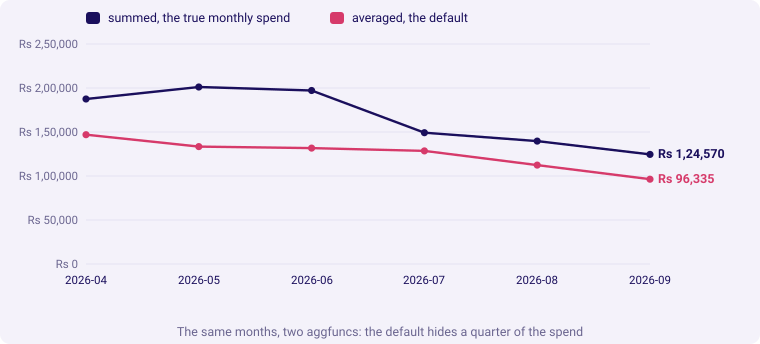

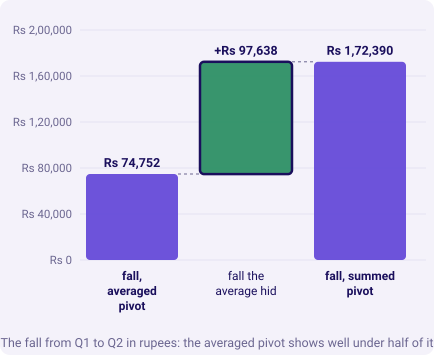

In [8]:
wide = plus.pivot_table(index="customer_id", columns="month", values="amount", aggfunc="sum", fill_value=0)
col = wide.sum()
q1_s, q2_s = col[MONTHS[:3]].sum(), col[MONTHS[3:]].sum()
kit.line(MONTHS, [("summed, the true monthly spend", col.tolist(), "lit"),
                  ("averaged, the default", col_wrong.round(0).tolist(), "bad")], fmt=kit.rupees,
         title="The same months, two aggfuncs: the default hides a quarter of the spend")
fall_w = round(q1_w) - round(q2_w)                 # the fall the averaged pivot reports, in whole rupees
kit.bridge(("fall, averaged pivot", fall_w), [("fall the average hid", round(q1_s - q2_s) - fall_w)],
           end_label="fall, summed pivot", lit=(0,),
           title="The fall from Q1 to Q2 in rupees: the averaged pivot shows well under half of it")
kit.check("the summed pivot adds back to every Retail-Plus order", wide.values.sum() == plus["amount"].sum(),
          kit.rupees(wide.values.sum()))
kit.check("the true fall from Q1 to Q2 is 29.4 percent", round(q2_s / q1_s - 1, 3) == -0.294, f"{q2_s / q1_s - 1:.1%}")

> **Kavya's review.** "Q1 Rs 5,85,770, Q2 Rs 4,13,380, a fall of 29 percent, from a pivot whose
> grand total equals the orders. The averaged pivot would have told the review 18. Write
> `aggfunc=` on every pivot, the way you write `how=` on every merge."

**Your turn, three minutes.** Kavya asks for the same view of the Retail-Core segment.
In the empty cell, build it with `aggfunc="sum"` and `fill_value=0` from the orders of
segment `Retail-Core`, check its grand total against those orders before you read a single
month, then say the Q1 to Q2 change aloud and whether the averaged pivot even gets its
direction right.

## 4. What does one row of the pivot stand for?

The index decides what one row is. Index the pivot by `order_id` and every order becomes a row:
a table of orders with five empty cells in each, which looks like a months view until someone
reads the row labels aloud.

**Predict before you run.** What shape is the pivot indexed by `order_id`? a) 107 rows by 6
columns; b) 355 rows by 6 columns; c) 6 rows by 107 columns; d) 120 rows by 6 columns.

index,shape,first row label,one row is
customer_id,"(107, 6)",C-0151,a member
order_id,"(355, 6)",KR-00125,an order


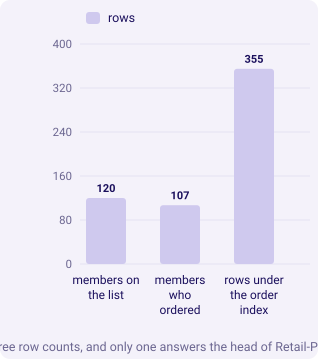

In [9]:
by_order = plus.pivot_table(index="order_id", columns="month", values="amount", aggfunc="sum")
kit.table(["index", "shape", "first row label", "one row is"],
          [("customer_id", str(wide.shape), wide.index[0], "a member"),
           ("order_id", str(by_order.shape), by_order.index[0], "an order")],
          caption="Read the row labels aloud before reading any number")
kit.columns(["members on the list", "members who ordered", "rows under the order index"],
            [("rows", [int((customers["segment"] == "Retail-Plus").sum()), len(wide), len(by_order)])],
            title="Three row counts, and only one answers the head of Retail-Plus")
kit.check("the member view has one row per member who ordered", len(wide) == plus["customer_id"].nunique() == 107)
kit.check("the order-indexed pivot has one row per order", len(by_order) == len(plus) == 355)
kit.check("its total is right, which is why it survives a glance", by_order.sum().sum() == plus["amount"].sum())

**What happened.** The answer is b, 355 rows, one per Retail-Plus order. Its totals are right,
which is why it survives a glance, but its rows are orders, so "who is drifting" cannot be read
from it at all. The member view has 107 rows. The 13 members on the list who never ordered are
in neither view, which is a decision to state when the view goes to the head of Retail-Plus.

## 5. Which shape compares a member's quarters, and which follows the tier's trend?

Months as columns answer a comparison: did this member spend less in Q2 than in Q1? Months as
rows answer a trend, and `melt` folds the wide table back into long, one row per member per
month, zeros included, which is the shape a chart of the months needs.

**Predict before you run.** How many rows does `melt` give from the 107-by-6 wide table?
a) 266, as the long table had; b) 642; c) 107; d) 6.

customer_id,Q1,Q2,change
C-0183,"Rs 16,310","Rs 7,140","-Rs 9,170"
C-0173,"Rs 16,170","Rs 4,320","-Rs 11,850"
C-0177,"Rs 15,160","Rs 4,350","-Rs 10,810"
C-0219,"Rs 14,250","Rs 6,390","-Rs 7,860"
C-0185,"Rs 13,560","Rs 3,350","-Rs 10,210"


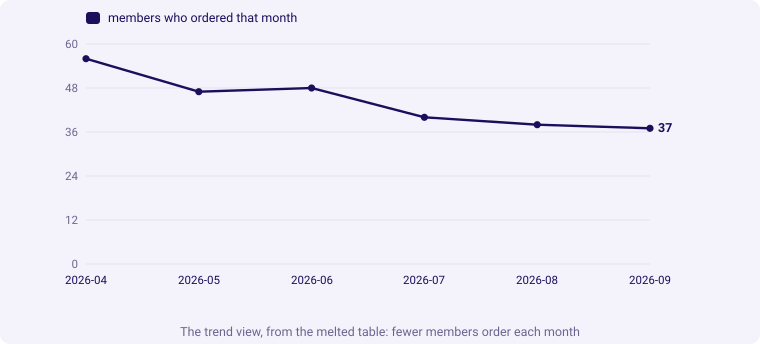

In [10]:
q = wide.assign(Q1=wide[MONTHS[:3]].sum(axis=1), Q2=wide[MONTHS[3:]].sum(axis=1))
fell, rose = int((q["Q2"] < q["Q1"]).sum()), int((q["Q2"] > q["Q1"]).sum())
kit.table(["customer_id", "Q1", "Q2", "change"],
          [(cid, kit.rupees(r.Q1), kit.rupees(r.Q2), kit.rupees(r.Q2 - r.Q1))
           for cid, r in q.sort_values("Q1", ascending=False).head(5).iterrows()],
          caption="The comparison view: the five largest Q1 members, their quarters side by side")
back = wide.reset_index().melt(id_vars="customer_id", var_name="month", value_name="spend")
buying = back[back["spend"] > 0].groupby("month")["customer_id"].nunique()
kit.line(MONTHS, [("members who ordered that month", buying.tolist(), "lit")],
         title="The trend view, from the melted table: fewer members order each month")

In [11]:
kit.check("melt gives 107 members times 6 months", len(back) == 107 * 6, f"{len(back)} rows")
kit.check("melt keeps every rupee", back["spend"].sum() == plus["amount"].sum())
kit.check("67 members spent less in Q2 than in Q1, and 40 spent more", fell == 67 and rose == 40)

**What happened.** The answer is b, 642 rows, because the wide table held a 0 for every month a
member did not order and `melt` keeps them. The comparison view shows 67 of 107 members spending
less in Q2 than in Q1, and the trend view shows the members who ordered each month falling from
56 in April to 37 in September: how often, again.

## 6. Does a query that never pivots give the same fall?

The fall came from a pivot's columns. The warehouse can reach the tier's two quarters with no
pivot and no months at all: join each order to its customer, keep Retail-Plus, and add up each
quarter. If this route disagrees with the pivot, one of them is wrong.

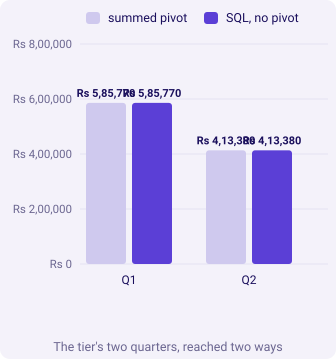

In [12]:
QUARTERS = """SELECT o.quarter, sum(o.amount) AS spend
FROM   orders o
JOIN   customers c ON c.customer_id = o.customer_id
WHERE  c.segment = 'Retail-Plus'
GROUP  BY o.quarter
ORDER  BY o.quarter;"""
by_sql = {r["quarter"]: float(r["spend"]) for r in kit.sql(QUARTERS)}
kit.columns(["Q1", "Q2"], [("summed pivot", [q1_s, q2_s]), ("SQL, no pivot", [by_sql["Q1"], by_sql["Q2"]])],
            fmt=kit.rupees, title="The tier's two quarters, reached two ways")
kit.check("SQL and the summed pivot agree on Q1", by_sql["Q1"] == q1_s, kit.rupees(by_sql["Q1"]))
kit.check("SQL and the summed pivot agree on Q2", by_sql["Q2"] == q2_s, kit.rupees(by_sql["Q2"]))
kit.check("both give a fall of 29.4 percent", round(by_sql["Q2"] / by_sql["Q1"] - 1, 3) == -0.294)

**When to switch.** The pivot is the route for the head of Retail-Plus's rows, since it keeps
each member's months. The quarter query is the route for the one number, and the route to
trust when the pivot's arguments are in doubt: it has no `aggfunc` to forget.

### How would you answer this chapter's questions in an interview?

**[F] Pivot against melt: which widens and which lengthens?** "`pivot` and `pivot_table`
widen: the values of one column become new columns, so a long table of member and month becomes
one row per member with a column per month. `melt` lengthens: it folds columns back into rows,
one row per member per month. I pivot to compare along a row and melt to plot or group a trend."

**[F] Your pivot's totals look low. Where do you look first?** "At `aggfunc`. `pivot_table`
averages by default, so where the cells should be totals I pass `aggfunc='sum'`, and I check
the pivot's grand total against the source before I read a single cell."

**[S] Pivot or pivot_table?** "`pivot` only reshapes, so it raises an error when a row and
column pair repeats; `pivot_table` combines the repeats, with the mean unless told otherwise.
When I expect one value per cell, `pivot` is the loud check."

### Going deeper: when does `pivot` refuse where `pivot_table` averages?

In [13]:
with kit.expect_error() as loud:
    plus.pivot(index="customer_id", columns="month", values="amount")
kit.check("pivot refuses to reshape when a member has two orders in a month",
          loud.name == "ValueError" and "duplicate entries" in loud.message, loud.message)

**The answers, question by question.**

1. The long table and the wide table together answer the head of Retail-Plus; a query per month
   would fix six months in its text.
2. Retail-Plus bought in 266 member-months, Rs 5,85,770 in Q1 and Rs 4,13,380 in Q2.
3. The one-line pivot reported a fall of 18 percent, because it averaged; summed, the fall is
   29.4 percent, Rs 1,72,390.
4. One row of the member pivot is a member, 107 of them; indexed by order it is an order, 355.
5. The wide table compares, with 67 members spending less in Q2; the long table follows, with
   members ordering each month falling from 56 to 37.
6. The warehouse, with no pivot, gives the same two quarters and the same fall of 29.4 percent.

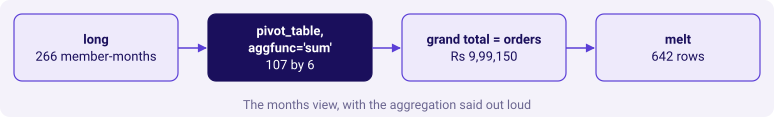

Next: chapter 4 asks one question in plain Python, SQL and pandas, and checks whether they agree.


In [14]:
kit.flow(["long\n266 member-months", "pivot_table, aggfunc='sum'\n107 by 6",
          "grand total = orders\nRs 9,99,150", "melt\n642 rows"], lit=1,
         title="The months view, with the aggregation said out loud")
kit.check_summary()
print("Next: chapter 4 asks one question in plain Python, SQL and pandas, and checks whether they agree.")